# Análisis Exploratorio de Datos (EDA)
## Predicción de precios de portátiles

Este notebook explora el dataset real de portátiles (Kaggle, "Laptop Price
Prediction" de Eslam Elsolia, adaptado con `data/prepare_kaggle_dataset.py`),
identifica patrones de mercado (marca, CPU, RAM, GPU, almacenamiento) y prepara
las conclusiones que justifican las decisiones de *feature engineering* tomadas
en `src/data_processing.py`.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_processing import load_data, clean_data

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Carga y vistazo general

In [2]:
df = load_data()
print(df.shape)
df.head()

(1303, 13)


,brand,laptop_type,cpu,ram_gb,storage_gb,storage_type,gpu,screen_size_in,resolution,touchscreen,weight_kg,os,price_usd
0,Apple,Ultrabook,Intel Core i5,8,128.0,SSD,Intel,13.3,2560x1600,0,1.37,macOS,1019.70
1,Apple,Ultrabook,Intel Core i5,8,128.0,SSD,Intel,13.3,1440x900,0,1.34,macOS,684.22
2,HP,Notebook,Intel Core i5 7200U,8,256.0,SSD,Intel,15.6,1920x1080,0,1.86,No OS,437.66
3,Apple,Ultrabook,Intel Core i7,16,512.0,SSD,AMD,15.4,2880x1800,0,1.83,macOS,1931.36
4,Apple,Ultrabook,Intel Core i5,8,256.0,SSD,Intel,13.3,2560x1600,0,1.37,macOS,1372.80


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   brand           1303 non-null   object 
 1   laptop_type     1303 non-null   object 
 2   cpu             1303 non-null   object 
 3   ram_gb          1303 non-null   int64  
 4   storage_gb      1303 non-null   float64
 5   storage_type    1303 non-null   object 
 6   gpu             1303 non-null   object 
 7   screen_size_in  1303 non-null   float64
 8   resolution      1303 non-null   object 
 9   touchscreen     1303 non-null   int64  
 10  weight_kg       1303 non-null   float64
 11  os              1303 non-null   object 
 12  price_usd       1303 non-null   float64
dtypes: float64(4), int64(2), object(7)
memory usage: 132.5+ KB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brand,1303,19,Dell,297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
laptop_type,1303,6,Notebook,727,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cpu,1303,93,Intel Core i5 7200U,193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ram_gb,1303.0,NaN,NaN,NaN,8.382195,5.084665,2.0,4.0,8.0,8.0,64.0
storage_gb,1303.0,NaN,NaN,NaN,447.80967,366.037159,8.0,256.0,256.0,512.0,2048.0
storage_type,1303,2,SSD,918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gpu,1303,4,Intel,722,NaN,NaN,NaN,NaN,NaN,NaN,NaN
screen_size_in,1303.0,NaN,NaN,NaN,15.017191,1.426304,10.1,14.0,15.6,15.6,18.4
resolution,1303,15,1920x1080,841,NaN,NaN,NaN,NaN,NaN,NaN,NaN
touchscreen,1303.0,NaN,NaN,NaN,0.147352,0.354593,0.0,0.0,0.0,0.0,1.0


## 2. Limpieza

In [5]:
df_clean = clean_data(df)
print(f"Filas antes: {len(df)} -> después de limpieza: {len(df_clean)}")
df_clean.isna().sum()

Filas antes: 1303 -> después de limpieza: 1274


brand             0
laptop_type       0
cpu               0
ram_gb            0
storage_gb        0
storage_type      0
gpu               0
screen_size_in    0
resolution        0
touchscreen       0
weight_kg         0
os                0
price_usd         0
dtype: int64

## 3. Distribución del precio

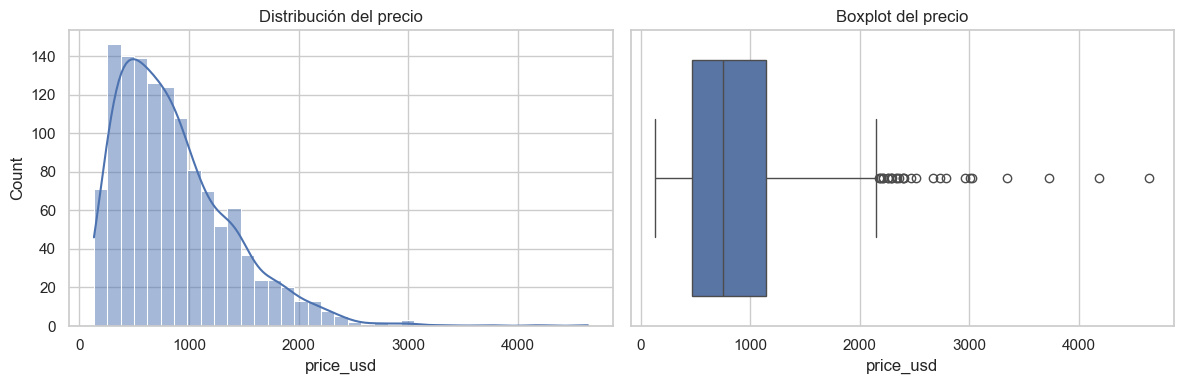

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_clean["price_usd"], kde=True, ax=ax[0])
ax[0].set_title("Distribución del precio")
sns.boxplot(x=df_clean["price_usd"], ax=ax[1])
ax[1].set_title("Boxplot del precio")
plt.tight_layout()
plt.show()

## 4. Precio por marca

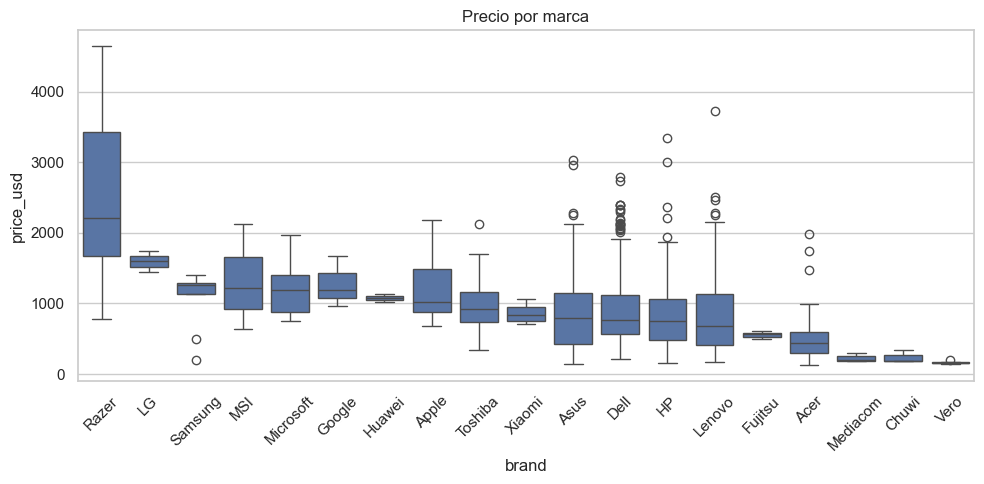

In [7]:
order = df_clean.groupby("brand")["price_usd"].median().sort_values(ascending=False).index
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x="brand", y="price_usd", order=order)
plt.xticks(rotation=45)
plt.title("Precio por marca")
plt.tight_layout()
plt.show()

## 5. Precio por CPU y RAM

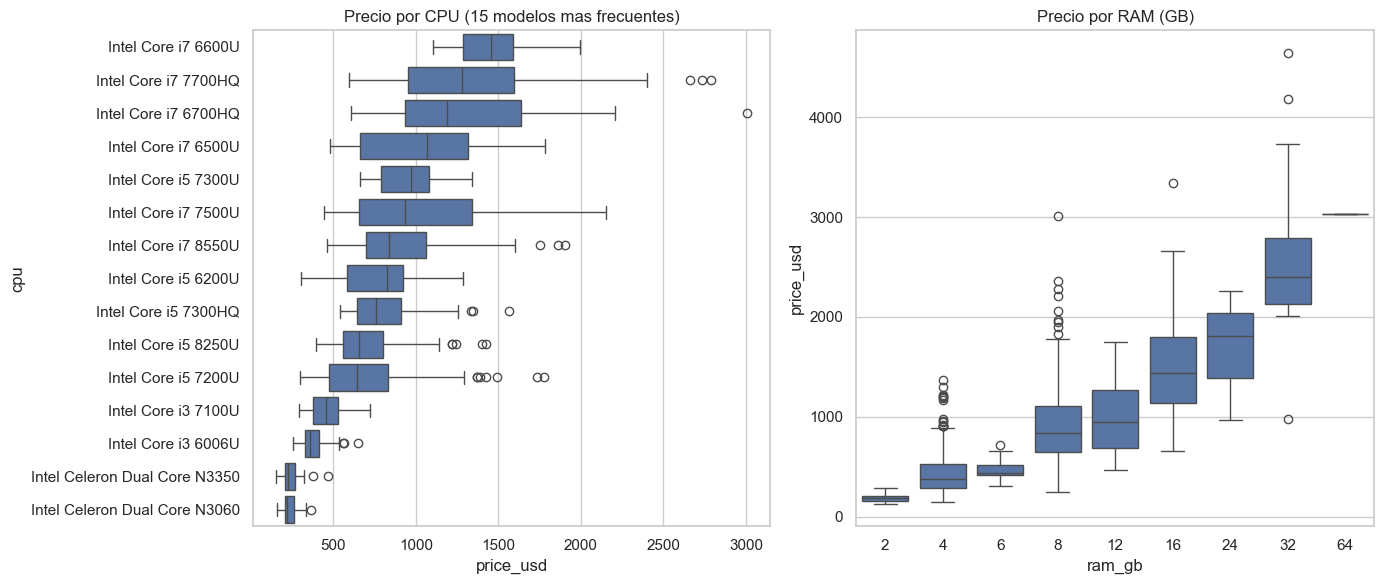

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

top_cpus = df_clean["cpu"].value_counts().head(15).index
df_top_cpu = df_clean[df_clean["cpu"].isin(top_cpus)]
order_cpu = df_top_cpu.groupby("cpu")["price_usd"].median().sort_values(ascending=False).index
sns.boxplot(data=df_top_cpu, y="cpu", x="price_usd", order=order_cpu, ax=ax[0])
ax[0].set_title("Precio por CPU (15 modelos mas frecuentes)")

sns.boxplot(data=df_clean, x="ram_gb", y="price_usd", ax=ax[1])
ax[1].set_title("Precio por RAM (GB)")
plt.tight_layout()
plt.show()

## 6. Matriz de correlación (variables numéricas)

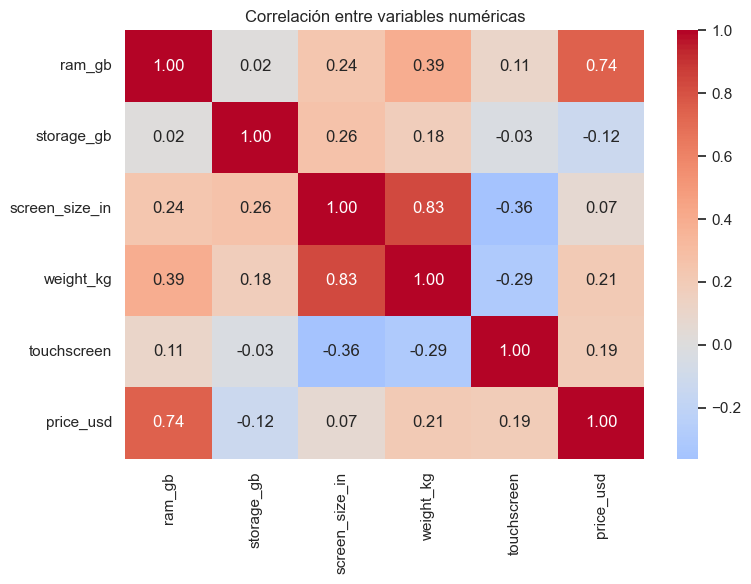

In [9]:
numeric_cols = ["ram_gb", "storage_gb", "screen_size_in", "weight_kg",
                "touchscreen", "price_usd"]
corr = df_clean[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación entre variables numéricas")
plt.tight_layout()
plt.show()

## 7. GPU y tipo de almacenamiento

C:\Users\usuario\AppData\Local\Temp\ipykernel_10496\3415580013.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45, ha="right")


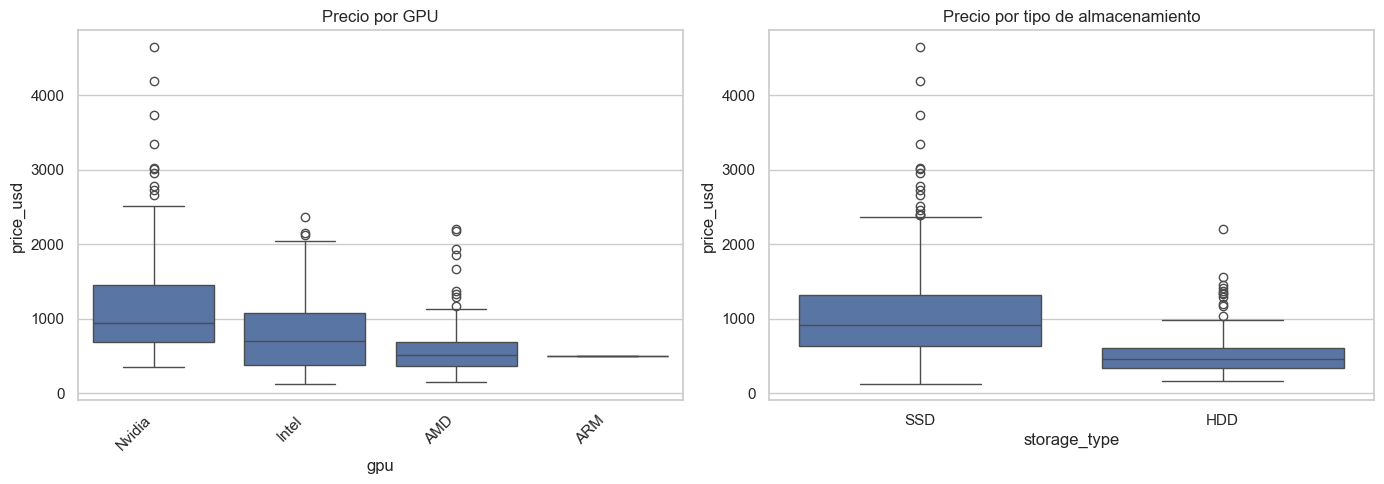

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
order_gpu = df_clean.groupby("gpu")["price_usd"].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x="gpu", y="price_usd", order=order_gpu, ax=ax[0])
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45, ha="right")
ax[0].set_title("Precio por GPU")

sns.boxplot(data=df_clean, x="storage_type", y="price_usd", ax=ax[1])
ax[1].set_title("Precio por tipo de almacenamiento")
plt.tight_layout()
plt.show()

## 8. Conclusiones

- El precio tiene una distribución con cola hacia la derecha (algunos portátiles
  premium de gama muy alta), por lo que conviene evaluar modelos robustos a
  outliers y revisar residuos en la fase de modelado.
- **Marca**, **CPU** y **GPU** son las variables categóricas con mayor impacto
  en el precio mediano. Apple y las GPU dedicadas de gama alta desplazan el
  precio claramente hacia arriba.
- **RAM** muestra correlación positiva con el precio,
  consistente con la lógica de mercado.
- Estas conclusiones justifican el pipeline de `ColumnTransformer`
  (One-Hot para categóricas + escalado estándar para numéricas) usado en
  `src/data_processing.py` antes de entrenar los modelos en
  `src/train_model.py`.